In [28]:
#| label: darkmode-setup
#| code-fold: true
#| output: asis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML

import statsmodels.formula.api as smf
from causalml.match import create_table_one
from joblib import Parallel, delayed
from sklearn.linear_model import LogisticRegression

def generate_data(N=300, seed=1):
  np.random.seed(seed)
  
  # Control variables
  male = np.random.binomial(1, 0.45, N)
  age = np.rint(18 + np.random.beta(2, 2, N)*50)
  hours = np.minimum(np.round(np.random.lognormal(5, 1.3, N), 1), 2000)
  
  # Treatment
  pr = np.maximum(0, np.minimum(1, 0.8 + 0.3*male - np.sqrt(age-18)/10))
  dark_mode = np.random.binomial(1, pr, N)==1
  
  # Outcome
  read_time = np.round(np.random.normal(10 - 4*male + 2*np.log(hours) + 2*dark_mode, 4, N), 1)

  # Generate the dataframe
  df = pd.DataFrame({'read_time': read_time, 'dark_mode': dark_mode, 'male': male, 'age': age, 'hours': hours})

  return df

user_df = generate_data(N=300)
ols_model = smf.ols("read_time ~ dark_mode", data=user_df).fit()
ols_summary = ols_model.summary()
results_as_html = ols_summary.tables[1].as_html()
HTML(results_as_html)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,19.1748,0.402,47.661,0.000,18.383,19.967
dark_mode[T.True],-0.4446,0.571,-0.779,0.437,-1.568,0.679


In [29]:
#| label: page-read-data
user_df.head()

,read_time,dark_mode,male,age,hours
0,14.4,False,0,43.0,65.6
1,15.4,False,1,55.0,125.4
2,20.9,True,0,23.0,642.6
3,20.0,False,0,41.0,129.1
4,21.5,True,0,29.0,190.2


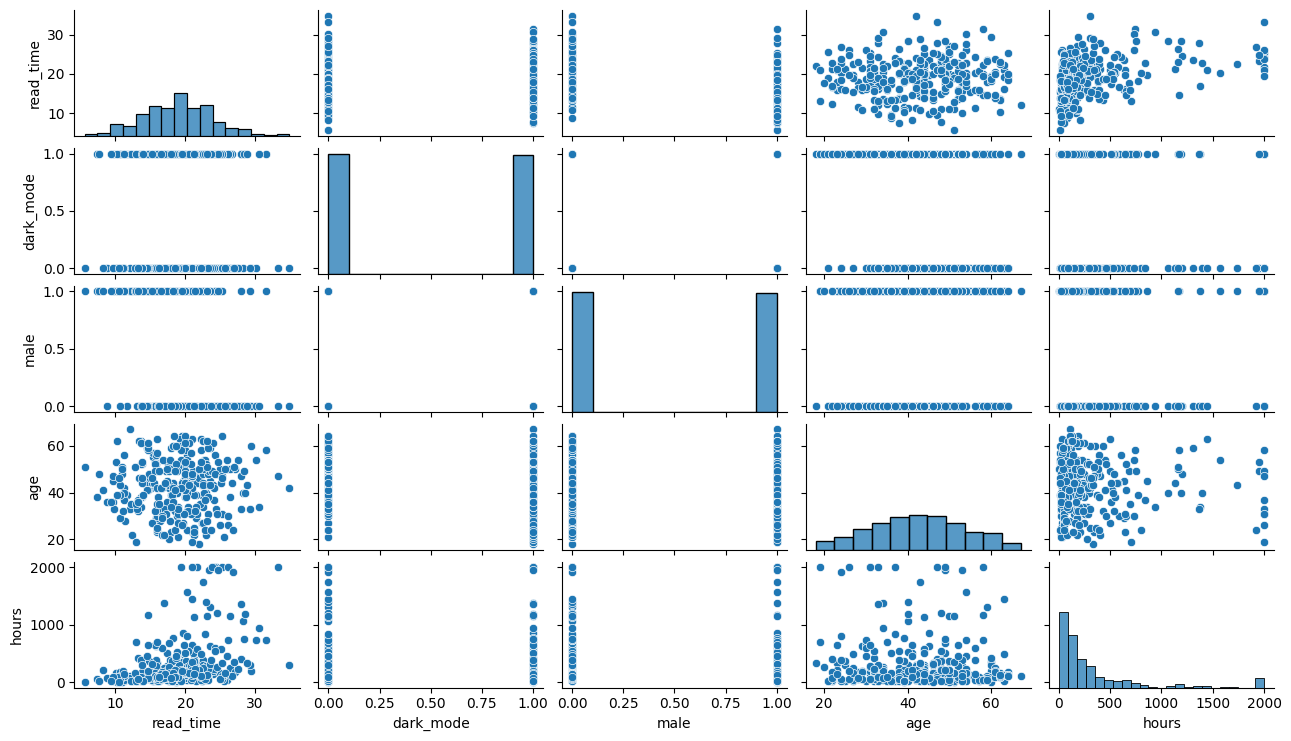

In [34]:
#| label: fig-darkmode-pairplot
#| fig-align: center
#| code-fold: true
#| fig-cap: Pairplot of variables in the light mode vs. dark mode dataset
import matplotlib
matplotlib.rcParams['axes.grid'] = False
matplotlib.rcParams['savefig.transparent'] = True
sns.pairplot(
  data=user_df,
  height=1.5, aspect=1.75,
)
plt.show()

In [35]:
#| label: darkmode-balance-table
#| df-print: kable
from IPython.display import display, HTML
X = ['male', 'age', 'hours']
table1 = create_table_one(user_df, 'dark_mode', X)
user_df.to_csv("assets/user_df.csv")
table1.to_csv("assets/table1.csv")
HTML(table1.to_html())

,Control,Treatment,SMD
Variable,,,
n,151,149,
age,46.01 (9.79),39.09 (11.53),-0.6469
hours,337.78 (464.00),328.57 (442.12),-0.0203
male,0.34 (0.47),0.66 (0.48),0.6732


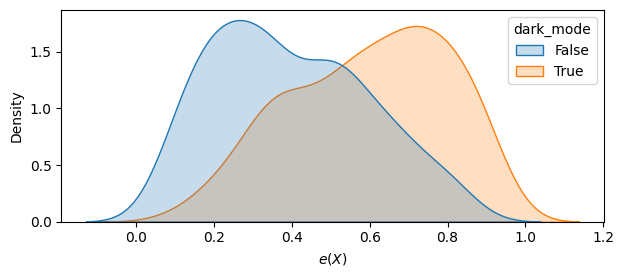

In [36]:
#| label: model1-propensity-score
#| fig-align: center
def estimate_e(df, X, D, model_e):
    e = model_e.fit(df[X], df[D]).predict_proba(df[X])[:,1]
    return e
user_df['e'] = estimate_e(user_df, X, "dark_mode", LogisticRegression())
fig, ax = plt.subplots(figsize=(7,2.75))
sns.kdeplot(
  x='e', hue='dark_mode', data=user_df,
  # bins=30,
  #stat='density',
  common_norm=False,
  fill=True,
  ax=ax
);
ax.set_xlabel("$e(X)$");

In [37]:
#| label: model1-result
#| code-fold: true
weights_denom = user_df['e'] * user_df["dark_mode"] + (1 - user_df['e']) * (1 - user_df["dark_mode"])
inv_weights = 1 / weights_denom
smf.wls(
  "read_time ~ dark_mode",
  weights=inv_weights,
  data=user_df
).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,18.5871,0.412,45.158,0.000,17.777,19.397
dark_mode[T.True],1.0486,0.581,1.805,0.072,-0.095,2.192


In [43]:
#| label: model2-sklearn
#| code-fold: true
from sklearn.linear_model import LinearRegression

def estimate_mu(df, X, D, y, model_mu):
  mu = model_mu.fit(df[X + [D]], df[y])
  mu0 = mu.predict(df[X + [D]].assign(dark_mode=0))
  mu1 = mu.predict(df[X + [D]].assign(dark_mode=1))
  return mu0, mu1

mu0, mu1 = estimate_mu(
  user_df, X, "dark_mode", "read_time", LinearRegression()
)
print(f'mean(mu0) = {np.mean(mu0):.2f}, mean(mu1) = {np.mean(mu1):.2f}')
print(f'Difference = {np.mean(mu1 - mu0):.2f}')

mean(mu0) = 18.27, mean(mu1) = 19.65
Difference = 1.39


In [39]:
#| label: model2-econml
#| code-fold: true
from econml.dr import LinearDRLearner

model = LinearDRLearner(
  model_propensity=LogisticRegression(),
  model_regression=LinearRegression(),
  random_state=5650
)
model.fit(Y=user_df["read_time"], T=user_df["dark_mode"], X=user_df[X]);
model.ate_inference(X=user_df[X].values, T0=0, T1=1).summary().tables[0]

mean_point,stderr_mean,zstat,pvalue,ci_mean_lower,ci_mean_upper
1.321,0.549,2.409,0.016,0.246,2.396


<positron-console-cell-44>:28: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.


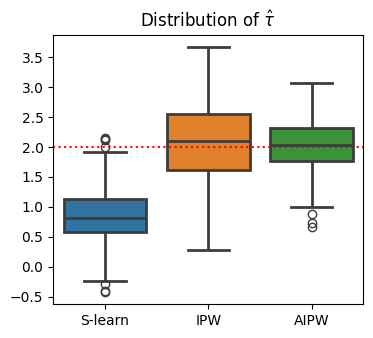

In [44]:
#| label: double-wrong-reg
#| fig-align: center
#| code-fold: true
def compare_estimators(X_e, X_mu, D, y, seed):
    df = generate_data(seed=seed)
    e = estimate_e(df, X_e, D, LogisticRegression())
    mu0, mu1 = estimate_mu(df, X_mu, D, y, LinearRegression())
    slearn = mu1 - mu0
    ipw = (df[D] / e - (1-df[D]) / (1-e)) * df[y]
    aipw = slearn + df[D] / e * (df[y] - mu1) - (1-df[D]) / (1-e) * (df[y] - mu0)
    return np.mean((slearn, ipw, aipw), axis=1)

def simulate_estimators(X_e, X_mu, D, y):
    r = Parallel(n_jobs=8)(delayed(compare_estimators)(X_e, X_mu, D, y, i) for i in range(100))
    df_tau = pd.DataFrame(r, columns=['S-learn', 'IPW', 'AIPW'])
    return df_tau
# The actual plots
fig, ax = plt.subplots(figsize=(4,3.5))
wrong_reg_df = simulate_estimators(
  X_e=['male', 'age'], X_mu=['hours'], D="dark_mode", y="read_time"
)
wrong_reg_plot = sns.boxplot(
  data=pd.melt(wrong_reg_df), x='variable', y='value', hue='variable',
  ax=ax,
  linewidth=2
);
wrong_reg_plot.set(
  title="Distribution of $\hat τ$", xlabel='', ylabel=''
);
ax.axhline(2, c='r', ls=':');

<positron-console-cell-45>:13: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.


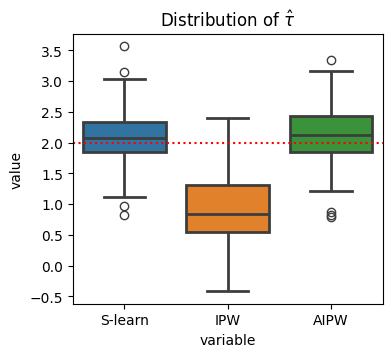

In [45]:
#| label: double-wrong-ps
#| code-fold: true
#| fig-align: center
fig, ax = plt.subplots(figsize=(4, 3.5))
wrong_ps_df = simulate_estimators(
  ['age'], ['male', 'hours'], D="dark_mode", y="read_time"
)
wrong_ps_plot = sns.boxplot(
  data=pd.melt(wrong_ps_df), x='variable', y='value', hue='variable',
  ax=ax,
  linewidth=2
);
ax.set_title("Distribution of $\hat τ$");
ax.axhline(2, c='r', ls=':');
plt.show()